In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from ROOT import TH1F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json
from ROOT import TCanvas
import statistics
import pandas as pd
#%jsroot on

Welcome to JupyROOT 6.30/04


In [2]:


#root.gStyle.SetOptStat(0)
root.gStyle.SetOptStat(1111)
palette = np.array([3,5,2], dtype=np.int32)
  
  
root.gStyle.SetTitleOffset( 1.3, "z" )
root.gStyle.SetLabelOffset( 0., "z" )
#root.gStyle.SetTitleSize(0.06,"z") 
root.gStyle.SetLabelSize(0.035,"z")
root.gStyle.SetPaintTextFormat("1.3f")
root.gStyle.SetPalette(1)
#root.gStyle.SetPaintTextFormat("1.1f");
root.gStyle.SetPaintTextFormat("4.3f")

   
###################################/ 
## THIS SCRIPT ASSUMES raw voltages in [V] and raw currents in [A] #
## Parameters below are in [V] and [uA]                            #
###################################/

n_wafer = 83 #
n_sensors = 8 #
start_wafer = 1 #first wafer number in the dataset
start_sensor = 1 #the first QC-TS of the wafer to be measured
start_gl_calculation = 70 #VGL calculated only if the number of bias points is larger than this value
save = False
verbose = True
write_json = False #produces the json file needed to upload the tests to the ETL database

dtz = datetime(2026, 6, 17, 12, 0, 0)
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))

invert_polarity=True

file_qa = root.TFile.Open("/Users/icosivi/Desktop/PRE-SERIE/FBK/PRE-SERIE_FBK_Torino_W16-S13_CV_uniformity.root")
tree_qa = file_qa.Get("Tree")

low_GL_bias = 15.  # 5 limite basso del fit (in voltaggio)
high_GL_bias = 45.  # 46 limite alto del fit (in voltaggio)
low_bulk_bias = 47.5  # 48 limite basso del fit (in voltaggio)
high_bulk_bias = 49.5  # 50 limite alto del fit (in voltaggio)
low_trail_bias = 55  # 50 limite basso del fit (in voltaggio)
Vbulk_upper_limit = 10. # as defined in Tender, if Vbulk above this value you will get an error message to check the measurement
k_high = 50.
k_low = 10.

bvoltage = False
bvoltage_hist = False
save = True

tests_json = []

vcount_vgl_qa = [[[0 for j in range(4)] for i in range(n_sensors)]  for k in range(n_wafer)]
vcount_bump_qa = [[[0 for j in range(4)] for i in range(n_sensors)]  for k in range(n_wafer)]
vvgl_qa = [[[0 for j in range(4)] for i in range(n_sensors)]  for k in range(n_wafer)]
vbulk_qa = [[[0 for j in range(4)] for i in range(n_sensors)]  for k in range(n_wafer)]
vcount_bump_qa_2d = [[0 for i in range(n_sensors)]  for k in range(n_wafer)]
vvgl_qa_2d = [[0 for i in range(n_sensors)]  for k in range(n_wafer)]
vbulk_qa_2d = [[0 for i in range(n_sensors)]  for k in range(n_wafer)]
vc_raw = [[[[] for j in range(4)] for i in range(n_sensors)]  for k in range(n_wafer)]
v_raw = [[[[] for j in range(4)] for i in range(n_sensors)]  for k in range(n_wafer)]
hVgl_qa = []
hVbulk_qa = []
hbump_qa = []
hcount_qa = []

# NOTA BENE #
# QC-TS comes in 3 different flavors; it is splitted in side A and B (FBK-LFoundry) #
sensor_type = 1 # 0=PIN,  1=LGAD, 2=1x2 LGAD array

side_number = 0 # The QC-TS has 2 sets of structures: one on the leftside of the array ("A" side_number == 0), one on the rightside ("B" side_number == 1), if side_number != 0,1 the two test structures are averaged in the wafer quality maps
side = "A"
#side = str()
#if side_number == 0:
#    side = "A"
#elif side_number == 1:
#    side = "B"
#else:
#    side = "averaged"

hbulk = TH1F( "vbulk_stats", r"V_{Bulk} (1x1 LGAD) - HPK pre-series", 50, 0, 15 )
hvgl = TH1F( "vgl_stats", r"V_{GL} uniformity - W16-S13 FBK pre-series", 20, 47, 52 )

for i in range(n_wafer):
    #hVgl_qa.append( TH2F( "Vgl_qa_W"+str(i+start_wafer), "VGL on-wafer W"+str(i+start_wafer)+" side "+str(side), 6,1,7,6,1,7 ) )
    #hVbulk_qa.append( TH2F( "Vbulk_qa_W"+str(i+start_wafer), "Vbulk on-wafer site W"+str(i+start_wafer)+" side "+str(side), 6,1,7,6,1,7 ) )
    hVgl_qa.append( TH2F( "Vgl_qa_W"+str(i+start_wafer), "VGL on-wafer W"+str(i+start_wafer), 6,1,7,6,1,7 ) )
    hVbulk_qa.append( TH2F( "Vbulk_qa_W"+str(i+start_wafer), "Vbulk on-wafer site W"+str(i+start_wafer), 6,1,7,6,1,7 ) )

dumb_counter = 0. # Total number of sensors/measurements in the root file
non_empty_counter = 0. # Sensors with both I and V arrays having size !=0 (the sensor was in fact measured)
non_zero_counter = 0. # Sensors with both I and V arrays having values !=0 (the sensor was measured and can be bias
good_fit_counter = 0. #Fraction of sensors whose category can be properly defined
cv_quality = bool()

'''
if(sensor_type==0):
 prefix_serial = "FBK_LF1_QC-TS_PIN_"
 sensor = "Prototype PIN"
 sensor_geom = "1x1 PIN"
elif(sensor_type==1):
 prefix_serial = "FBK_LF1_QC-TS_LGAD_"
 sensor = "Prototype LGAD"
 sensor_geom = "1x1 LGAD"
else:
 prefix_serial = "FBK_LF1_QC-TS_1x2_"
 sensor = "Prototype LGAD"
 sensor_geom = "1x2 LGAD"
'''
  
#vendor = "FBK"
#production = "UFSD-LF"
user = "fsiviero" # cern user of who's uploading the test
location = "HPK" # where the test was performed

if(write_json):
    json_filename="Test_Array_Vendor_CV_"+side

save_path = '/Users/icosivi/Desktop/PRE-SERIE/HPK/'
#save_path = '/Users/icosivi/Desktop/PRE-SERIE/HPK/CV_plots/'

wb = pd.read_excel('/Users/icosivi/Desktop/PRE-SERIE/HPK/HPK_QC-TS_PRE-SERIES.xlsx') # excel that maps 'serial number --> vendor, batch, wafer, row, column'
  

Best bulk fit range for W16_S13_evt0: [48.99, 49.39]  n_points=3  peak_slope=1.2544306930051167e+23
48.94986324956128 0
Best bulk fit range for W16_S13_evt1: [49.42, 49.81]  n_points=3  peak_slope=1.5946156125209835e+23
49.43091664565671 1
Best bulk fit range for W16_S13_evt2: [48.81, 49.18]  n_points=3  peak_slope=1.4802335305981574e+23
48.7859212370714 2
Best bulk fit range for W16_S13_evt3: [49.02, 49.36]  n_points=3  peak_slope=1.8093798925842804e+23
49.040560563881414 3
Best bulk fit range for W16_S13_evt4: [48.42, 48.8]  n_points=3  peak_slope=1.5961611374305458e+23
48.36919418106468 4
Best bulk fit range for W16_S13_evt5: [48.83, 49.17]  n_points=3  peak_slope=2.366733817424685e+23
48.829689302236424 5
Best bulk fit range for W16_S13_evt6: [48.62, 49.0]  n_points=3  peak_slope=1.4219503009031754e+23
48.5845768246813 6
Best bulk fit range for W16_S13_evt7: [49.21, 49.57]  n_points=3  peak_slope=1.773733133717949e+23
49.1931108087453 7
Best bulk fit range for W16_S13_evt8: [48.58,

Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/FBK_W16-S13/W16_S13_evt0_CVfit.png has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/FBK_W16-S13/W16_S13_evt0.root has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/FBK_W16-S13/W16_S13_evt1_CVfit.png has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/FBK_W16-S13/W16_S13_evt1.root has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/FBK_W16-S13/W16_S13_evt2_CVfit.png has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/FBK_W16-S13/W16_S13_evt2.root has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/FBK_W16-S13/W16_S13_evt3_CVfit.png has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/FBK_W16-S13/W16_S13_evt3.root has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/FBK_W16-S13/W16_S13_evt4_CVfit.png has been created
Info i

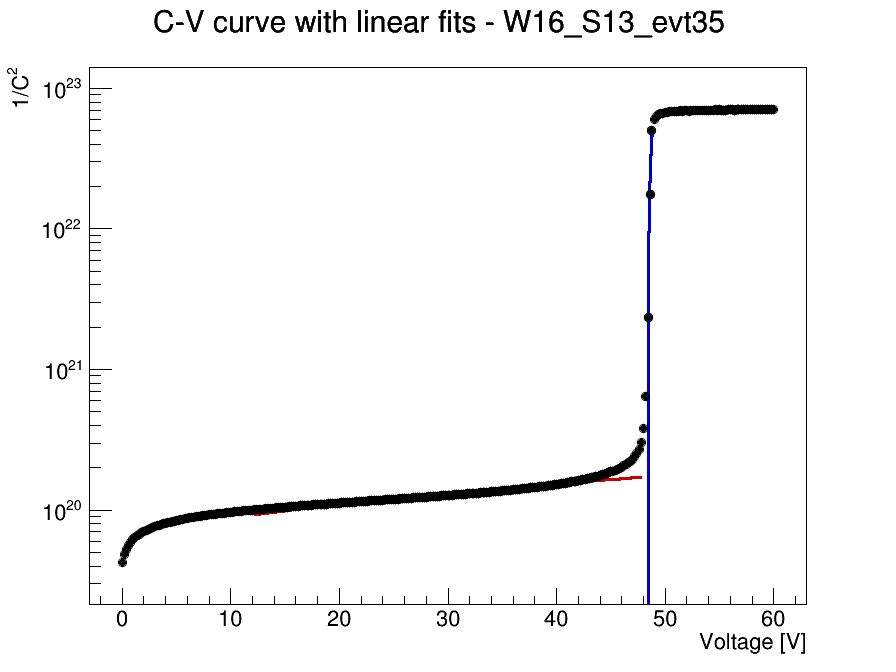

In [3]:

# IMPORTANT: please check the if conditions below and choose whether you want to display only side A/B on the wafer quality maps or average the two (if both have been measured)

for event in tree_qa:
  #if event.type==sensor_type: #if different types of QC-TS are present in your root file
  #if event.side==side_number: # use this condition to select one QC-TS side ('A'=0; 'B'=1), only the chosen side will show up on the wafer quality map
  #if True: # use this selection to average 'A' and 'B' on the wafer quality map cell
    dumb_counter+=1
    if(int(event.CPAD.size())>=start_gl_calculation and int(event.V.size())>=start_gl_calculation ):
      non_empty_counter+=1

      if( event.CPAD.at(event.CPAD.size()-1)<0 ): 
        Cpad = [float(-i) for i in event.CPAD]
        #for idx, i in enumerate(event.CPAD):  
        #  if(idx<=event.V.size()-1):
        #   vc_raw[event.wafer-start_wafer][event.sensor-start_sensor][event.side].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Cpad = [i for i in event.CPAD]
        #for idx, i in enumerate(event.CPAD):  
        #  if(idx<=event.V.size()-1):
        #   vc_raw[event.wafer-start_wafer][event.sensor-start_sensor][event.side].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        #for idx, i in enumerate(event.V):  
         #if(idx<=event.CPAD.size()-1):
         #  v_raw[event.wafer-start_wafer][event.sensor-start_sensor][event.side].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        #for idx, i in enumerate(event.V): 
        #  if(idx<=event.CPAD.size()-1): 
        #   v_raw[event.wafer-start_wafer][event.sensor-start_sensor][event.side].append(float(i))
           

      non_zero_capacitance = sum(Cpad) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_capacitance!=0):
        non_zero_counter+=1
    
        cv_quality = True
        VGL_CV = -1000.
        Vbulk_CV = -1000.
        evt_tag = "W"+str(event.wafer)+"_S"+str(event.sensor)+"_evt"+str(event.event)
      
        V_GL_vector = []
        C_GL_vector = []
        V_GL_vector_error = []
        C_GL_vector_error = []
        bulk_cand_V = []
        bulk_cand_C = []
        bulk_cand_C_error = []
        V_trail_vector = []
        C_trail_vector = []
        V_trail_vector_error = []
        C_trail_vector_error = []
        
        ####### VGL calculation #####
        for i in range(len(Cpad)-1):

          if Vbias[i]>=low_GL_bias and Vbias[i]<=high_GL_bias:
  
            V_GL_vector.append(float(Vbias[i]))
            C_GL_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_GL_vector_error.append(0.06)
            C_GL_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
  
          # candidate points for the adaptive bulk fit range search below (must stay strictly between high_GL_bias and low_trail_bias)
          if Vbias[i]>high_GL_bias and Vbias[i]<low_trail_bias:
  
            bulk_cand_V.append(float(Vbias[i]))
            bulk_cand_C.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            bulk_cand_C_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
          
          #if Vbias[i]>high_bulk_bias and Vbias[i]<Vbias[len(Vbias)-1]: # orignal method
          if Vbias[i]>low_trail_bias and Vbias[i]<Vbias[len(Vbias)-1]: # a la Matteo
  
            V_trail_vector.append(float(Vbias[i]))
            C_trail_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_trail_vector_error.append(0.06)
            C_trail_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
        
        V_GL_vector = np.array(V_GL_vector)
        C_GL_vector = np.array(C_GL_vector)
        V_trail_vector = np.array(V_trail_vector)
        C_trail_vector = np.array(C_trail_vector)
        Vbias = np.array(Vbias)
        Cpad = np.array(1/(np.array(Cpad)*np.array(Cpad)))
        bulk_cand_V = np.array(bulk_cand_V)
        bulk_cand_C = np.array(bulk_cand_C)

        ####### adaptive bulk fit range search #######
        # the bulk region is the few, near-vertical points where the C-V curve's slope changes
        # abruptly between the GL and trail plateaus. Detect them from the local point-to-point
        # slope: find the steepest segment (the "knee"), then grow the window outward while the
        # neighbouring slope stays above a fraction of the peak slope (half-max style peak width)
        bulk_slope_frac_thresh = 0.5

        bulk_slopes = np.diff(bulk_cand_C) / np.diff(bulk_cand_V)
        i_peak = int(np.argmax(np.abs(bulk_slopes)))
        peak_slope = abs(bulk_slopes[i_peak])

        i_lo_seg = i_peak
        while i_lo_seg>0 and abs(bulk_slopes[i_lo_seg-1])>=bulk_slope_frac_thresh*peak_slope:
          i_lo_seg -= 1
        i_hi_seg = i_peak
        while i_hi_seg<len(bulk_slopes)-1 and abs(bulk_slopes[i_hi_seg+1])>=bulk_slope_frac_thresh*peak_slope:
          i_hi_seg += 1

        i_lo_pt, i_hi_pt = i_lo_seg, i_hi_seg+1
        while (i_hi_pt-i_lo_pt+1)<3:
          if i_lo_pt>0:
            i_lo_pt -= 1
          elif i_hi_pt<len(bulk_cand_V)-1:
            i_hi_pt += 1
          else:
            break

        V_bulk_vector = bulk_cand_V[i_lo_pt:i_hi_pt+1]
        C_bulk_vector = bulk_cand_C[i_lo_pt:i_hi_pt+1]
        lo_best, hi_best = V_bulk_vector[0], V_bulk_vector[-1]
        print("Best bulk fit range for "+evt_tag+": ["+str(round(lo_best,2))+", "+str(round(hi_best,2))+"]  n_points="+str(len(V_bulk_vector))+"  peak_slope="+str(peak_slope))

        g_GL = root.TGraph(len(V_GL_vector),V_GL_vector,C_GL_vector)
        g_bulk = root.TGraph(len(V_bulk_vector),V_bulk_vector,C_bulk_vector)
        g_trail = root.TGraph(len(V_trail_vector),V_trail_vector,C_trail_vector)
        g_total = root.TGraph(len(Vbias),Vbias,Cpad)

        g_GL.Fit("pol1","Q")
        f_gl = g_GL.GetFunction("pol1")
        chi_gl = f_gl.GetChisquare()/f_gl.GetNDF()
        
        g_bulk.Fit("pol1","Q")
        f_bulk = g_bulk.GetFunction("pol1")
        chi_bulk = f_bulk.GetChisquare()/f_bulk.GetNDF()
        
        g_trail.Fit("pol1","Q")
        f_trail = g_trail.GetFunction("pol1")
        chi_trail = f_trail.GetChisquare()/f_trail.GetNDF()
        
        #print("Chi2: "+str(chi_gl)+" "+str(chi_bulk)+" "+str(chi_trail))
        
        g_GL.SetMarkerStyle(20)
        g_bulk.SetMarkerStyle(20)
        g_trail.SetMarkerStyle(20)
        g_total.SetMarkerStyle(20)
        g_GL.SetLineWidth(0)
        g_bulk.SetLineWidth(0)
        g_trail.SetLineWidth(0)
        g_total.SetLineWidth(0)

        mg = root.TMultiGraph()
        mg.SetName("W"+str(event.wafer)+"_S"+str(event.sensor))
        mg.Add(g_GL,"lp")
        mg.Add(g_bulk,"cp")
        mg.Add(g_trail,"cp")
        mg.Add(g_total,"cp")

        ####### one plot per event: mg (TMultiGraph) with the 3 pol1 fits (GL, bulk, trail) overlaid, saved to disk #######
        c_total_single = root.TCanvas("c_total_"+evt_tag, "C-V curve with fits "+evt_tag, 900, 700)
        c_total_single.SetLogy()

        # y-range covering the full curve (g_total uses raw Cpad, the three region graphs use 1/C^2 -- combine both)
        all_y_for_range = np.concatenate([Cpad, C_GL_vector, C_bulk_vector, C_trail_vector])
        all_y_positive = all_y_for_range[all_y_for_range > 0]
        y_lo = all_y_positive.min() * 0.5 if all_y_positive.size else 1e-6
        y_hi = all_y_positive.max() * 2.0 if all_y_positive.size else 1.0
        mg.SetMinimum(y_lo)
        mg.SetMaximum(y_hi)

        mg.SetTitle("C-V curve with linear fits - "+evt_tag+";Voltage [V];1/C^{2}")
        mg.Draw("apl")

        f_gl.SetLineColor(root.kRed+1)
        f_gl.SetLineWidth(3)
        f_gl.Draw("same")

        f_bulk.SetLineColor(root.kBlue+1)
        f_bulk.SetLineWidth(3)
        f_bulk.Draw("same")

        f_trail.SetLineColor(root.kGreen+2)
        f_trail.SetLineWidth(3)
        f_trail.Draw("same")

        # star marker at (VGL_CV, y) -- x from the GL/bulk fit intersection, y read off the same fit curve (mg)
        VGL_CV_star = (f_bulk.GetParameter(0)-f_gl.GetParameter(0))/(f_gl.GetParameter(1)-f_bulk.GetParameter(1))
        VGL_CV_star_y = f_gl.Eval(VGL_CV_star)
        star_marker = root.TMarker(VGL_CV_star, VGL_CV_star_y, 29)
        star_marker.SetMarkerColor(root.kMagenta+2)
        star_marker.SetMarkerSize(2.5)
        star_marker.Draw("same")

        leg_fit = root.TLegend(0.15, 0.7, 0.5, 0.89)
        leg_fit.AddEntry(mg, "C-V data", "lp")
        leg_fit.AddEntry(f_gl, "GL fit", "l")
        leg_fit.AddEntry(f_bulk, "bulk fit", "l")
        leg_fit.AddEntry(f_trail, "trail fit", "l")
        leg_fit.AddEntry(star_marker, "VGL_CV", "p")
        leg_fit.Draw()

        c_total_single.Modified()
        c_total_single.Update()
        c_total_single.SaveAs("/Users/icosivi/Desktop/FBK_W16-S13/"+evt_tag+"_CVfit.png")

        mg.Draw("apl")
        mg.SaveAs("/Users/icosivi/Desktop/FBK_W16-S13/W"+str(event.wafer)+"_S"+str(event.sensor)+"_evt"+str(event.event)+".root")
        
        f_GL = g_GL.GetFunction("pol1")
        f_bulk = g_bulk.GetFunction("pol1")
        f_trail = g_trail.GetFunction("pol1")

        m_GL = f_GL.GetParameter(1)
        q_GL = f_GL.GetParameter(0)
        m_bulk = f_bulk.GetParameter(1)
        q_bulk = f_bulk.GetParameter(0)
        m_trail = f_trail.GetParameter(1)
        q_trail = f_trail.GetParameter(0)


        VGL_CV = (q_bulk-q_GL)/(m_GL-m_bulk)
        Vbulk_CV = (q_trail-q_bulk)/(m_bulk-m_trail) - VGL_CV
        print(str(VGL_CV)+" "+str(event.event))
        
        #if( VGL_CV>low_GL_bias and VGL_CV<high_bulk_bias and Vbulk_CV>0. and Vbulk_CV<Vbulk_upper_limit ):
        if( VGL_CV>low_GL_bias and Vbulk_CV>0. ):
          good_fit_counter += 1
          '''
          vvgl_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.side] += VGL_CV
          vbulk_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.side] += Vbulk_CV
          vcount_bump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.side] += 1 
          vvgl_qa_2d[event.wafer-start_wafer][event.sensor-start_sensor] += VGL_CV
          vbulk_qa_2d[event.wafer-start_wafer][event.sensor-start_sensor] += Vbulk_CV
          vcount_bump_qa_2d[event.wafer-start_wafer][event.sensor-start_sensor] += 1 
          '''
          hbulk.Fill(Vbulk_CV)
          hvgl.Fill(VGL_CV)
        else: 
          #vcount_bump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.side] += -1000
          if(verbose):
            print("Sensor from wafer "+str(event.wafer)+" sensor "+str(event.event)+"  : VGL could not be calculated. PLEASE CHECK.")
      else:
        #vcount_bump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.side] += -1000
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" sensor "+str(event.sensor)+"  has Voltage and/or Capacitance always equal to zero. PLEASE CHECK.")
    else:
      #vcount_bump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.side] += -1000
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" sensor "+str(event.sensor)+" : Voltage and/or Capacitance vectors have less than "+str(start_gl_calculation)+" elements. PLEASE CHECK.")
        

print("Succesful fits: "+str(float(good_fit_counter/dumb_counter)*100)+" %")
print("Succesful fits (only non empty CVs): "+str(float(good_fit_counter/non_zero_counter)*100)+" %")
print("Non empty CVs: "+str(float(non_zero_counter/dumb_counter)*100)+" %")

with open(save_path+"Vbulk_list.json", 'w') as f:
   json.dump(vbulk_qa, f, indent=4)

with open(save_path+"VGL_list.json", 'w') as f:
   json.dump(vvgl_qa, f, indent=4)

In [ ]:
root.gStyle.SetOptFit(111)          
cx = TCanvas( "c_vbulk", "c_vbulk", 900,900)
cx.cd()
gaus_func1 = root.TF1("gaus_vbulk", "gaus", 2, 15)
hbulk.GetXaxis().SetTitle(r"V_{bulk}  [V]")
hbulk.GetXaxis().SetTitleOffset(1.3)
hbulk.SetLineWidth(2)
hbulk.Draw()
#hbulk.Fit(gaus_func1,'R')
root.gPad.SetGrid(1,1)
root.gPad.Draw()
cx.Modified()
cx.Update()

In [ ]:
root.gStyle.SetOptFit(111)  
cy = TCanvas( "c_vgl", "c_vgl", 900,900)
cy.cd()
gaus_func1 = root.TF1("gaus_vgl", "gaus", 47, 52)
hvgl.GetXaxis().SetTitle(r"V_{GL}  [V]")
hvgl.GetXaxis().SetTitleOffset(1.3)
hvgl.SetLineWidth(2)
hvgl.Draw()
hvgl.Fit(gaus_func1,'R')
root.gPad.SetGrid(1,1)
root.gPad.Draw()
cy.Modified()
cy.Update()

In [ ]:
wafer_values = []
for entry in tree_qa:
        wafer_values.append(entry.wafer-start_wafer)
        #wafer_real_numbers.append(entry.wafer)

wafer_real_numbers = [i+1 for i in range(n_wafer)]
vgl_list = [[] for i in range(n_wafer)]
vbulk_list = [[] for i in range(n_wafer)]

In [ ]:
sensor_positions = [[2,6],[5,6],[6,5],[6,2],[5,1],[2,1],[1,2],[1,5]]

for i in range(n_wafer):
    for j in range(n_sensors):
          if i in wafer_values:
          #if( i<20 ):
             if(vcount_bump_qa_2d[i][j] > 0):
               hVgl_qa[i].Fill( sensor_positions[j][0], sensor_positions[j][1], vvgl_qa_2d[i][j]/vcount_bump_qa_2d[i][j])
               hVbulk_qa[i].Fill( sensor_positions[j][0], sensor_positions[j][1], vbulk_qa_2d[i][j]/vcount_bump_qa_2d[i][j] )
               vgl_list[i].append(vvgl_qa_2d[i][j]/vcount_bump_qa_2d[i][j])
               vbulk_list[i].append(vbulk_qa_2d[i][j]/vcount_bump_qa_2d[i][j])

if(verbose):
  print("Fraction of non-empty CVs: "+str(non_empty_counter/dumb_counter))
  print("Fraction of CVs with non-zero values: "+str(non_zero_counter/dumb_counter))
  print("Fraction of succesfull fits: "+str(good_fit_counter/non_zero_counter))

In [ ]:
sensor_positions = [[2,6],[5,6],[6,5],[6,2],[5,1],[2,1],[1,2],[1,5]]

for i in range(n_wafer):
    for j in range(n_sensors):
        for k in range(4):
            if i in wafer_values:
                if(vcount_bump_qa[i][j][k] > 0):
                    pippo = {'component': str(wb[(wb['Wafer'] == i+start_wafer) & (wb['Sensor Number'] == j+start_sensor)]['SerialNumber'].iloc[0]),
                        'name': 'Sensor Test Array CV',
                        'measurement_date': dtz.isoformat(),
                        'location': location,
                        'user_created': user,
                        'version': 'v0',
                        'vgl': vvgl_qa[i][j][k]/vcount_bump_qa[i][j][k],
                        'vbulk': vbulk_qa[i][j][k]/vcount_bump_qa[i][j][k],
                        'side': k,
                        'geometry': '1x1 LGAD',
                        'gain_category': None,
                        'voltage': v_raw[i][j][k],
                        'capacitance': vc_raw[i][j][k]
                       }
                    tests_json.append(pippo)
  
                if(vcount_bump_qa[i][j][k]<0): 
                    pippo = {'component': str(wb[(wb['Wafer'] == i+start_wafer) & (wb['Sensor Number'] == j+start_sensor)]['SerialNumber'].iloc[0]),
                        'name': 'Sensor Test Array CV',
                        'measurement_date': dtz.isoformat(),
                        'location': location,
                        'user_created': user,
                        'version': 'v0',
                        'vgl': None,
                        'vbulk': None,
                        'side': k,
                        'geometry': '1x1 LGAD',
                        'gain_category': None,
                        'voltage': v_raw[i][j][k],
                        'capacitance': vc_raw[i][j][k]
                       }
               
                    tests_json.append(pippo)

if write_json:
 with open(save_path+json_filename+".json", 'w') as f:
   json.dump(tests_json, f, indent=4)

In [ ]:
mean_array_bulk = []
sigma_array_bulk = []
mean_array_vgl = []
sigma_array_vgl = []

for i in vbulk_list:
  if not len(i)==0:
    mean_array_bulk.append(statistics.mean(i))
    sigma_array_bulk.append(statistics.stdev(i))
  else:
    mean_array_bulk.append(0)
    sigma_array_bulk.append(0)


for v in vgl_list:
  if not len(v)==0:
    mean_array_vgl.append(statistics.mean(v))
    sigma_array_vgl.append(statistics.stdev(v))
  else:
    mean_array_vgl.append(0)
    sigma_array_vgl.append(0)

with open(save_path+"mean_Vbulk.json", 'w') as f:
   json.dump(mean_array_bulk, f, indent=4)
   
with open(save_path+"sigma_Vbulk.json", 'w') as f:
   json.dump(mean_array_bulk, f, indent=4)

with open(save_path+"mean_VGL.json", 'w') as f:
   json.dump(mean_array_vgl, f, indent=4)

with open(save_path+"sigma_VGL.json", 'w') as f:
   json.dump(sigma_array_vgl, f, indent=4)

In [ ]:
plt.figure(figsize=(36, 12))
plt.errorbar(wafer_real_numbers, mean_array_vgl,yerr=sigma_array_vgl,linewidth=0,elinewidth=2,capsize=4,fmt='o-',markersize=14,color='orange')
plt.xlabel('Wafer number',fontsize=28,labelpad=20)
plt.ylabel("$V_{GL}$  [V]",fontsize=28,labelpad=20)
plt.ylim(34.2,35.2)
plt.title('$V_{GL}$ by wafer - HPK pre-series',fontsize=28, y=1.04)
y_ticks_m = np.arange(34.2, 35.2, 0.1)
x_ticks_m = np.arange(0, 84, 1)
plt.yticks(y_ticks_m,fontsize=22)
plt.xticks(x_ticks_m, fontsize=18, rotation=45, ha='right')
#plt.xticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.grid(True,linestyle='--', alpha=0.7)
plt.show()

In [ ]:
plt.figure(figsize=(36, 12))
plt.errorbar(wafer_real_numbers, mean_array_bulk,yerr=sigma_array_bulk,linewidth=0,elinewidth=2,capsize=4,fmt='o-',markersize=14)
plt.xlabel('Wafer number',fontsize=28,labelpad=20)
plt.ylabel("$V_{Bulk}$  [V]",fontsize=28,labelpad=20)
plt.ylim(2,12)
plt.title('$V_{Bulk}$ by wafer - HPK pre-series',fontsize=28, y=1.04)
y_ticks_m = np.arange(2, 12, 0.5)
x_ticks_m = np.arange(0, 84, 1)
plt.yticks(y_ticks_m,fontsize=22)
plt.xticks(x_ticks_m, fontsize=18, rotation=45, ha='right')
#plt.xticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.grid(True,linestyle='--', alpha=0.7)
plt.show()

In [ ]:
cC = []

for i in range(n_wafer):
    cC.append(root.TCanvas("c_V_W"+str(i+start_wafer), "c VGL_W"+str(i+start_wafer), 1000,1000))

for i in range(n_wafer):
 if i in wafer_values:
 #if( i<20 ):
    hVgl_qa[i].GetZaxis().SetRangeUser( 34.2, 35.2 ) # Tender acceptance ranges
    hVgl_qa[i].GetZaxis().SetTitle("[V]")
    hVgl_qa[i].GetXaxis().SetTitle("column") 
    hVgl_qa[i].GetYaxis().SetTitle("row")
    hVgl_qa[i].SetMarkerSize(3.)

    root.gStyle.SetPaintTextFormat("4.2f")
    #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
    cC[i].SetRightMargin(0.15)
    cC[i].cd()
    hVgl_qa[i].SetMarkerSize(0.9)
    hVgl_qa[i].Draw("textcolz")
    root.gPad.SetGrid(1,1)
    root.gPad.Update()
    cC[i].Update()
    hVgl_qa[i].GetXaxis().SetNdivisions(6)
    hVgl_qa[i].GetYaxis().SetNdivisions(6)
  
    if(save): 
      cC[i].SaveAs(save_path+"/Torino_tests/QC-TS/VGL_W"+str(i+start_wafer)+".png")    

In [ ]:
cD = []

for i in range(n_wafer):
    cD.append(root.TCanvas("c_Vb_W"+str(i+start_wafer), "c Vbulk_W"+str(i+start_wafer), 1000,1000))

for i in range(n_wafer):
 if i in wafer_values:
 #if( i<20 ):
    hVbulk_qa[i].GetZaxis().SetRangeUser( 2., 12. ) # Tender acceptance ranges
    hVbulk_qa[i].GetZaxis().SetTitle("[V]")
    hVbulk_qa[i].GetXaxis().SetTitle("column") 
    hVbulk_qa[i].GetYaxis().SetTitle("row")
    hVbulk_qa[i].SetMarkerSize(3.)

    root.gStyle.SetPaintTextFormat("4.2f")
    #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
    cD[i].SetRightMargin(0.15)
    cD[i].cd()
    hVbulk_qa[i].SetMarkerSize(0.9)
    hVbulk_qa[i].Draw("textcolz")
    root.gPad.SetGrid(1,1)
    root.gPad.Update()
    cD[i].Update()
    hVbulk_qa[i].GetXaxis().SetNdivisions(6)
    hVbulk_qa[i].GetYaxis().SetNdivisions(6)
  
    if(save): 
      cD[i].SaveAs(save_path+"Vbulk_W"+str(i+start_wafer)+"_side_"+str(side)+".png")   